# **Physics-Informed Neural Network for 1D Heat Equation**

This Python code uses the PyTorch library to create and train a Physics-Informed Neural Network (PINN). The goal is to find an approximate solution to the 1D heat equation (ut​=αuxx​) over a specified time and space domain.

It works by training a neural network not just on data points, but also by making sure its output satisfies the heat equation itself, as well as the given initial temperature distribution (t=0) and boundary conditions (at x=0 and x=L). Automatic differentiation (autograd) is used to calculate the derivatives (u_t​, u_xx​) needed to check if the network's output respects the physics of the heat equation.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Configuration ---
ALPHA = 0.1  # Thermal diffusivity
T_DOMAIN = [0.0, 1.0]  # Time domain
X_DOMAIN = [0.0, 1.0]  # Spatial domain

# Network Architecture
HIDDEN_LAYERS = [20, 20, 20, 20] # Number of neurons in each hidden layer

# Training Hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 15000
N_COLLOCATION = 10000  # Number of points inside the domain for PDE loss
N_BOUNDARY = 1000     # Number of points on each boundary (t=0, x=0, x=L)
N_INITIAL = 1000      # Number of points for initial condition (can be same as N_BOUNDARY)

# Weights for loss components (can be tuned)
W_PDE = 1.0
W_IC = 1.0
W_BC = 1.0

# --- Define the PINN Model ---
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        # Build the network dynamically from the layers list
        modules = []
        for i in range(len(layers) - 1):
            modules.append(nn.Linear(layers[i], layers[i+1]))
            # Use Tanh activation for all but the last layer
            if i < len(layers) - 2:
                modules.append(nn.Tanh())
        self.network = nn.Sequential(*modules)

    def forward(self, t, x):
        # Concatenate time and space coordinates as input
        inputs = torch.cat([t, x], dim=1)
        return self.network(inputs)

# --- Physics-Informed Loss Function ---
def physics_informed_loss(model, t_coll, x_coll, t_ic, x_ic, u_ic, t_bc, x_bc0, x_bcL):
    """
    Calculates the total physics-informed loss.

    Args:
        model (PINN): The neural network model.
        t_coll, x_coll: Collocation points (inside domain) for PDE residual.
        t_ic, x_ic, u_ic: Points and values for the initial condition loss.
        t_bc, x_bc0, x_bcL: Points for the boundary condition loss (x=0 and x=L).
    """
    # 1. PDE Residual Loss (Collocation Points)
    # ----------------------------------------
    u_pred = model(t_coll, x_coll)

    # Use autograd to compute derivatives
    # torch.autograd.grad(outputs, inputs, grad_outputs=..., create_graph=True, retain_graph=True)
    # Need create_graph=True to compute higher-order derivatives
    u_t = torch.autograd.grad(
        u_pred, t_coll,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
        retain_graph=True
    )[0]
    u_x = torch.autograd.grad(
        u_pred, x_coll,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
        retain_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x_coll,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True # Keep graph if using u_x later (we don't here, but good practice)
    )[0]

    # Calculate the PDE residual: u_t - alpha * u_xx
    pde_residual = u_t - ALPHA * u_xx
    loss_pde = torch.mean(pde_residual**2)

    # 2. Initial Condition Loss (t=0)
    # -------------------------------
    u_pred_ic = model(t_ic, x_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)

    # 3. Boundary Condition Loss (x=0 and x=L)
    # ----------------------------------------
    # Predict u at x=0 boundary
    u_pred_bc0 = model(t_bc, x_bc0)
    loss_bc0 = torch.mean(u_pred_bc0**2) # Target is u(t, 0) = 0

    # Predict u at x=L boundary
    u_pred_bcL = model(t_bc, x_bcL)
    loss_bcL = torch.mean(u_pred_bcL**2) # Target is u(t, L) = 0

    loss_bc = loss_bc0 + loss_bcL

    # Total Weighted Loss
    # -------------------
    total_loss = W_PDE * loss_pde + W_IC * loss_ic + W_BC * loss_bc
    return total_loss, loss_pde, loss_ic, loss_bc

# --- Helper Functions ---
def initial_condition(x):
    """Defines the initial condition u(0, x) = sin(pi*x)"""
    return torch.sin(torch.pi * x)

def analytical_solution(t, x):
    """Analytical solution for u(0,x)=sin(pi*x) and BCs=0"""
    return torch.exp(-ALPHA * (torch.pi**2) * t) * torch.sin(torch.pi * x)


In [3]:
# --- Prepare Training Data ---
# Collocation points (random points inside the t-x domain)
t_coll = torch.rand(N_COLLOCATION, 1, device=device) * (T_DOMAIN[1] - T_DOMAIN[0]) + T_DOMAIN[0]
x_coll = torch.rand(N_COLLOCATION, 1, device=device) * (X_DOMAIN[1] - X_DOMAIN[0]) + X_DOMAIN[0]
t_coll.requires_grad = True # IMPORTANT: Needed for derivative calculation
x_coll.requires_grad = True # IMPORTANT: Needed for derivative calculation

# Initial condition points (at t=0)
t_ic = torch.zeros((N_INITIAL, 1), device=device) # t=0
x_ic = torch.rand(N_INITIAL, 1, device=device) * (X_DOMAIN[1] - X_DOMAIN[0]) + X_DOMAIN[0]
u_ic = initial_condition(x_ic) # Compute target u values at t=0

# Boundary condition points (at x=0 and x=L)
t_bc = torch.rand(N_BOUNDARY, 1, device=device) * (T_DOMAIN[1] - T_DOMAIN[0]) + T_DOMAIN[0]
x_bc0 = torch.zeros((N_BOUNDARY, 1), device=device) # x=0
x_bcL = torch.ones((N_BOUNDARY, 1), device=device) * X_DOMAIN[1] # x=L (assuming L=1)

# --- Initialize Model and Optimizer ---
input_dim = 2 # t, x
output_dim = 1 # u
layers = [input_dim] + HIDDEN_LAYERS + [output_dim]
pinn_model = PINN(layers).to(device)
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=LEARNING_RATE)

# --- Training Loop ---
print("Starting training...")
start_time = time.time()
loss_history = []
pde_loss_history = []
ic_loss_history = []
bc_loss_history = []

for epoch in range(EPOCHS):
    pinn_model.train() # Set model to training mode

    # Zero gradients
    optimizer.zero_grad()

    # Calculate loss
    total_loss, loss_pde, loss_ic, loss_bc = physics_informed_loss(
        pinn_model, t_coll, x_coll, t_ic, x_ic, u_ic, t_bc, x_bc0, x_bcL
    )

    # Backpropagation
    total_loss.backward()

    # Update weights
    optimizer.step()

    # Store losses for plotting
    loss_history.append(total_loss.item())
    pde_loss_history.append(loss_pde.item())
    ic_loss_history.append(loss_ic.item())
    bc_loss_history.append(loss_bc.item())

    # Print progress
    if (epoch + 1) % 1000 == 0:
        elapsed_time = time.time() - start_time
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss.item():.4e}, "
              f"PDE: {loss_pde.item():.4e}, IC: {loss_ic.item():.4e}, BC: {loss_bc.item():.4e}, "
              f"Time: {elapsed_time:.2f}s")
        start_time = time.time() # Reset timer for next block

print("Training finished.")

Starting training...
Epoch [1000/15000], Loss: 4.1275e-04, PDE: 3.5394e-04, IC: 6.5718e-06, BC: 5.2243e-05, Time: 10.06s
Epoch [2000/15000], Loss: 1.5103e-04, PDE: 8.7437e-05, IC: 6.0981e-06, BC: 5.7490e-05, Time: 9.74s
Epoch [3000/15000], Loss: 1.1393e-04, PDE: 6.5599e-05, IC: 3.9668e-06, BC: 4.4365e-05, Time: 10.88s
Epoch [4000/15000], Loss: 9.1176e-05, PDE: 5.4077e-05, IC: 3.3007e-06, BC: 3.3798e-05, Time: 9.81s
Epoch [5000/15000], Loss: 8.3384e-05, PDE: 4.5966e-05, IC: 6.6445e-06, BC: 3.0774e-05, Time: 9.85s
Epoch [6000/15000], Loss: 6.1793e-05, PDE: 3.8213e-05, IC: 3.8140e-06, BC: 1.9766e-05, Time: 9.85s
Epoch [7000/15000], Loss: 5.2105e-05, PDE: 3.1698e-05, IC: 4.1400e-06, BC: 1.6266e-05, Time: 9.32s
Epoch [8000/15000], Loss: 4.5805e-05, PDE: 2.7899e-05, IC: 4.4252e-06, BC: 1.3480e-05, Time: 9.44s
Epoch [9000/15000], Loss: 1.1530e-04, PDE: 2.6757e-05, IC: 4.7270e-05, BC: 4.1271e-05, Time: 9.61s
Epoch [10000/15000], Loss: 3.8254e-05, PDE: 2.3378e-05, IC: 4.5259e-06, BC: 1.0350e-05

L2 Relative Error: 2.9826e-03


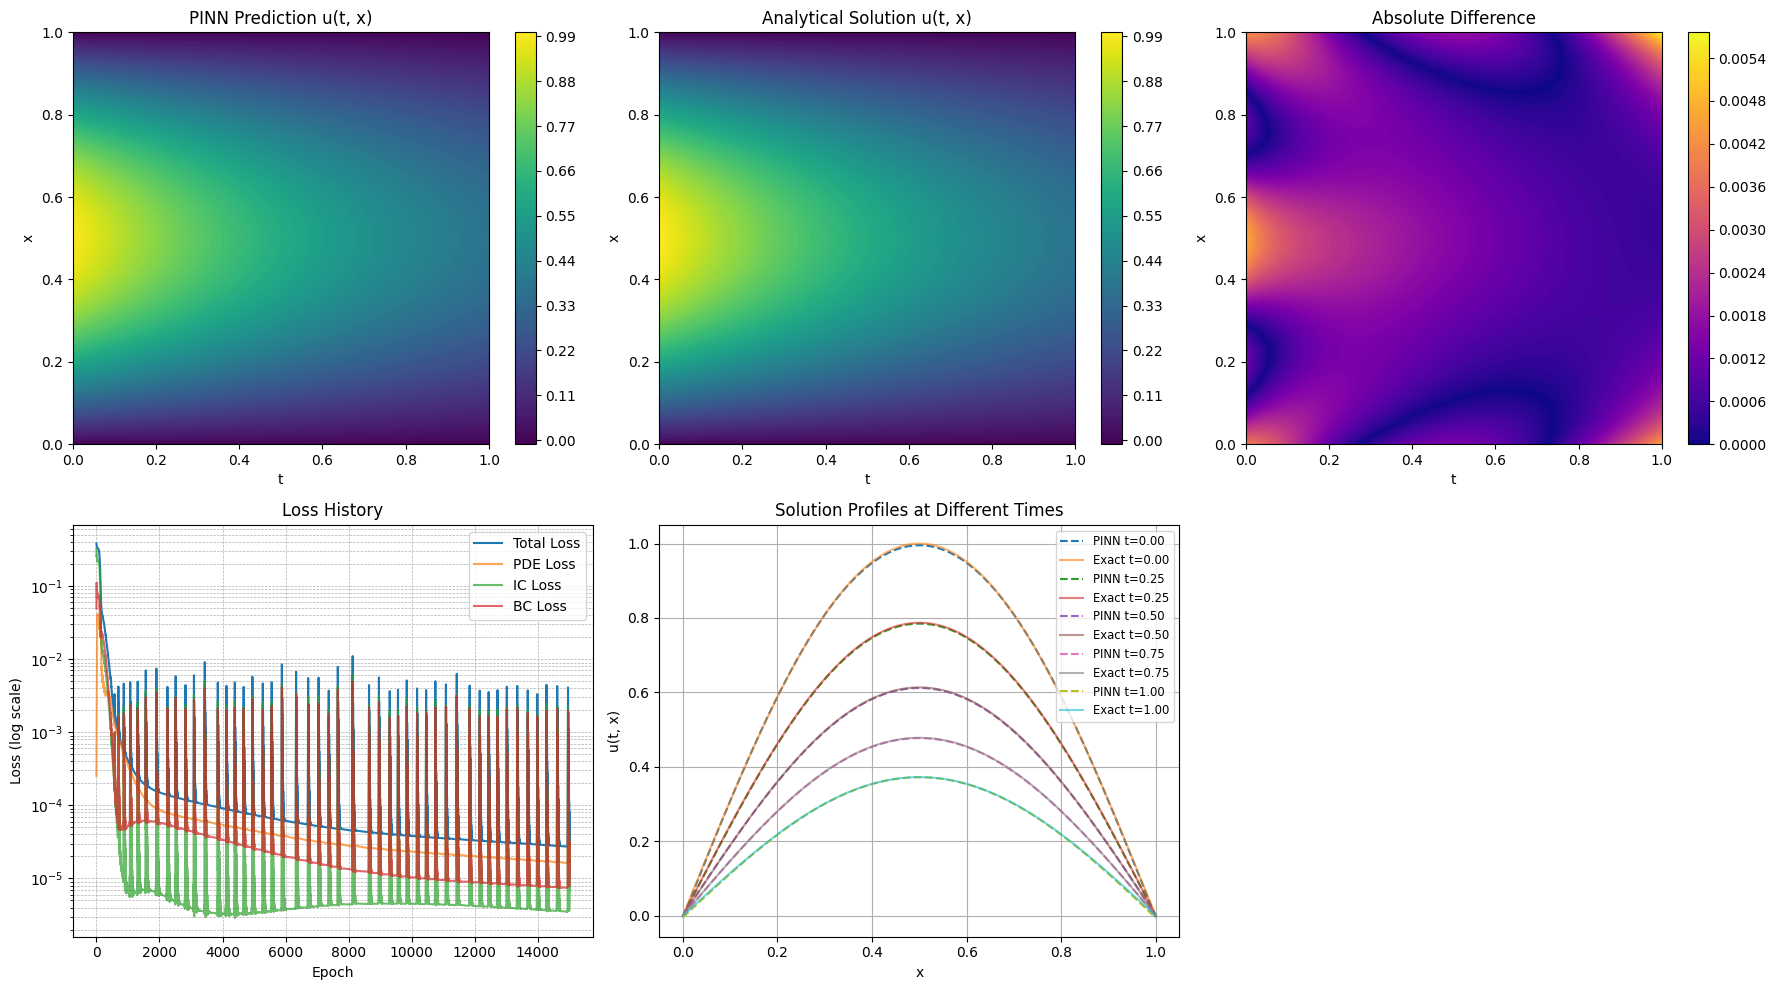

In [4]:
# --- Evaluation and Plotting ---
pinn_model.eval() # Set model to evaluation mode

# Create a grid for plotting
t_plot = torch.linspace(T_DOMAIN[0], T_DOMAIN[1], 100, device=device)
x_plot = torch.linspace(X_DOMAIN[0], X_DOMAIN[1], 100, device=device)
T_grid, X_grid = torch.meshgrid(t_plot, x_plot, indexing='ij')

# Flatten grid for model input
T_flat = T_grid.flatten().unsqueeze(1)
X_flat = X_grid.flatten().unsqueeze(1)

# Predict using the trained model
with torch.no_grad(): # Disable gradient calculation for evaluation
    U_pred_flat = pinn_model(T_flat, X_flat)
U_pred = U_pred_flat.reshape(T_grid.shape)

# Calculate analytical solution on the grid
U_analytical = analytical_solution(T_grid, X_grid)

# Calculate L2 relative error
l2_error = torch.linalg.norm(U_pred - U_analytical) / torch.linalg.norm(U_analytical)
print(f"L2 Relative Error: {l2_error.item():.4e}")

# Move tensors to CPU for plotting
T_grid_cpu = T_grid.cpu().numpy()
X_grid_cpu = X_grid.cpu().numpy()
U_pred_cpu = U_pred.cpu().numpy()
U_analytical_cpu = U_analytical.cpu().numpy()
U_diff_cpu = np.abs(U_pred_cpu - U_analytical_cpu)

# Plotting
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.contourf(T_grid_cpu, X_grid_cpu, U_pred_cpu, levels=100, cmap='viridis')
plt.colorbar()
plt.title('PINN Prediction u(t, x)')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(2, 3, 2)
plt.contourf(T_grid_cpu, X_grid_cpu, U_analytical_cpu, levels=100, cmap='viridis')
plt.colorbar()
plt.title('Analytical Solution u(t, x)')
plt.xlabel('t')
plt.ylabel('x')

plt.subplot(2, 3, 3)
plt.contourf(T_grid_cpu, X_grid_cpu, U_diff_cpu, levels=100, cmap='plasma')
plt.colorbar()
plt.title('Absolute Difference')
plt.xlabel('t')
plt.ylabel('x')

# Plot loss history
plt.subplot(2, 3, 4)
plt.plot(loss_history, label='Total Loss')
plt.plot(pde_loss_history, label='PDE Loss', alpha=0.7)
plt.plot(ic_loss_history, label='IC Loss', alpha=0.7)
plt.plot(bc_loss_history, label='BC Loss', alpha=0.7)
plt.yscale('log')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot solution at specific time steps
plt.subplot(2, 3, 5)
times_to_plot = [0.0, 0.25, 0.5, 0.75, 1.0]
t_indices = [int(t / (T_DOMAIN[1]-T_DOMAIN[0]) * 99) for t in times_to_plot]
for i, idx in enumerate(t_indices):
    plt.plot(X_grid_cpu[idx, :], U_pred_cpu[idx, :], '--', label=f'PINN t={times_to_plot[i]:.2f}')
    plt.plot(X_grid_cpu[idx, :], U_analytical_cpu[idx, :], '-', label=f'Exact t={times_to_plot[i]:.2f}', alpha=0.6)
plt.title('Solution Profiles at Different Times')
plt.xlabel('x')
plt.ylabel('u(t, x)')
plt.legend(fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()